# Does the Monday suite hold on Finance's definition, the orders that were delivered?

**Week 2, Monday. The escalated case, alone, in five parts.** Parts 1 and 2 run in the
afternoon session; parts 3 to 5 run in the practice lab.

> "Finance counts the orders that reached the customer and stayed there. Run me the same suite
> on delivered orders, and tell me whether the story changes."
> Anand Iyer, finance controller, Kalpa Retail

**The situation.** The chapters built the Monday suite on booked revenue, every order at its
amount whatever its status: Rs 10,00,00,000 in Q1 (April to June 2026) and Rs 9,84,00,000 in Q2
(July to September 2026), 244 then 227 customers who bought, and Retail-Plus carrying the fall
with its revenue down 29.4 percent. Finance's definition counts only delivered orders; a
cancelled or returned order is not revenue on it. This notebook reruns the suite on that
definition. Its numbers are new, so nothing from the chapters can be copied.

**The data.** The Kalpa warehouse, as in the chapters: `orders` (1,000 rows: order id, customer
id, date, quarter, channel, amount, status) and `customers` (340 rows, one per customer, with
the segment). The segment is looked up with `JOIN customers c USING (customer_id)`. Spend per
member is the rupees a Retail-Plus member spent in a quarter, averaged over the members who
took delivery in either quarter, so both quarters are averaged over the same people.

**This is the solution.** Every marker is filled with its key and the notebook runs clean from the
top; the reasons for each key are at the end.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
from decimal import Decimal
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D01_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def statements(block):
    """A block's statements with its comment lines removed, for a block that runs several."""
    bare = "\n".join(l for l in block.splitlines() if not l.strip().startswith("--"))
    return [s.strip() for s in bare.split(";") if s.strip()]

def num(v):
    """A database number as a Python int or float."""
    if isinstance(v, Decimal):
        return int(v) if v == v.to_integral_value() else float(v)
    return v

def show(rows, caption="", money=(), limit=12):
    """Rows from kit.sql as the kit's table, with the columns named in money set in rupees."""
    if not rows:
        kit.table(["result"], [["no rows"]], caption)
        return
    heads = list(rows[0])
    def cell(h, v):
        v = num(v)
        if v is None:
            return "NULL"
        if h in money:
            return kit.rupees(v)
        return f"{v:,}" if isinstance(v, int) and abs(v) >= 10000 else str(v)
    body = [[cell(h, r[h]) for h in heads] for r in rows[:limit]]
    if len(rows) > limit:
        body.append(["..." for _ in heads])
    kit.table(heads, body, caption)

def run(name, caption="", money=(), limit=12):
    """Print a named block, run it, show its rows and hand them back."""
    print(Q[name])
    rows = kit.sql(Q[name])
    show(rows, caption, money, limit)
    return rows

def pct(before, after):
    """The change from before to after, in percent."""
    return 100 * (float(after) - float(before)) / float(before)

def rows(query):
    """Run a query and hand back its rows with every number as a Python number."""
    return [{k: num(v) for k, v in r.items()} for r in kit.sql(query)]
print("connected:", kit.sql("select version()")[0]["version"].split(",")[0])

connected: PostgreSQL 16.14 (Ubuntu 16.14-0ubuntu0.24.04.1) on x86_64-pc-linux-gnu


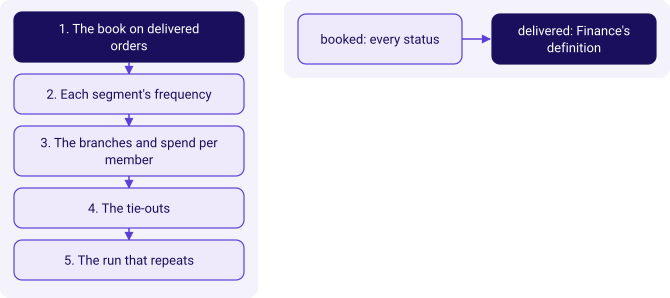

In [2]:
kit.side_by_side(
    kit.ladder(["The book on delivered orders", "Each segment's frequency", "The branches and spend per member",
                "The tie-outs", "The run that repeats"], lit=0, show=False),
    kit.flow(["booked: every status", "delivered: Finance's definition"], kinds=["plain", "lit"], show=False),
)

## Part 1. What does the book say on Finance's definition?

Where this is used at work: every finance number starts from a definition of revenue, and the
filter that states it is the first line an auditor reads.

SELECT quarter, count(*) AS orders, count(DISTINCT customer_id) AS customers, sum(amount) AS revenue
FROM orders WHERE status = 'delivered' GROUP BY quarter ORDER BY quarter


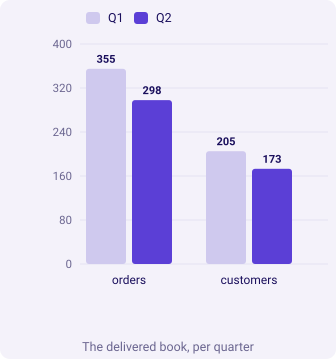

In [3]:
# TODO 1. Which filter keeps the orders that reached the customer and stayed there?
#   a) WHERE status <> 'cancelled'
#   b) WHERE status = 'delivered'
#   c) WHERE amount > 0
#   d) WHERE status <> 'returned'
FILTER = {"a": "WHERE status <> 'cancelled'", "b": "WHERE status = 'delivered'",
          "c": "WHERE amount > 0", "d": "WHERE status <> 'returned'"}["b"]

# TODO 2. Which expression counts the customers who took delivery in a quarter, each once?
#   a) count(*), since each delivered row belongs to a customer who took delivery
#   b) count(customer_id), since it counts the customer column rather than the rows
#   c) count(DISTINCT customer_id), one per customer id however many rows carry it
#   d) sum(1), since adding one per delivered order counts everyone who received one
CUSTOMERS = {"a": "count(*)", "b": "count(customer_id)", "c": "count(DISTINCT customer_id)",
             "d": "sum(1)"}["c"]

book_sql = f"""SELECT quarter, count(*) AS orders, {CUSTOMERS} AS customers, sum(amount) AS revenue
FROM orders {FILTER} GROUP BY quarter ORDER BY quarter"""
print(book_sql)
book = {r["quarter"]: r for r in rows(book_sql)}
kit.columns(["orders", "customers"], [(q, [book[q]["orders"], book[q]["customers"]]) for q in ("Q1", "Q2")],
            title="The delivered book, per quarter")

In [4]:
leftover = rows(f"SELECT count(*) AS n FROM orders {FILTER} AND status <> 'delivered'")[0]["n"]
kit.check("every order the filter keeps reached the customer and stayed there", leftover == 0,
          f"{leftover} kept with another status")
kit.check("customers are fewer than orders in each quarter",
          all(book[q]["customers"] < book[q]["orders"] for q in ("Q1", "Q2")))
kit.check("no quarter shows more customers than the 340 on the book",
          all(book[q]["customers"] <= 340 for q in ("Q1", "Q2")))
print(f"Revenue {kit.rupees(book['Q1']['revenue'])} to {kit.rupees(book['Q2']['revenue'])}, "
      f"{pct(book['Q1']['revenue'], book['Q2']['revenue']):+.1f}%; customers {book['Q1']['customers']} "
      f"to {book['Q2']['customers']}, {pct(book['Q1']['customers'], book['Q2']['customers']):+.1f}%")

Revenue Rs 6,80,25,200 to Rs 6,65,65,090, -2.1%; customers 205 to 173, -15.6%


## Part 2. Which segment's frequency fell on delivered orders, and which groups are too thin?

Where this is used at work: a per-segment rate is the line a business head reads first, and a
rate on too few customers is the line that misleads them most.

In [5]:
# TODO 3. Predict before you run it: how many rows will the query grouped by c.segment, o.quarter return?
#   a) 8, one for each segment in each quarter
#   b) 4, one for each segment over both quarters
#   c) 2, one for each quarter over all segments
#   d) 653, one for each delivered order
PREDICTED_ROWS = {"a": 8, "b": 4, "c": 2, "d": 653}["a"]

# TODO 4. Which orders-per-customer figure survives the analyst's multiply-back check?
#   a) round(count(*) / count(DISTINCT o.customer_id), 2)
#   b) count(*) / count(DISTINCT o.customer_id)
#   c) round(count(DISTINCT o.customer_id)::numeric / count(*), 2)
#   d) round(count(*)::numeric / count(DISTINCT o.customer_id), 2)
RATIO = {"a": "round(count(*) / count(DISTINCT o.customer_id), 2)",
         "b": "count(*) / count(DISTINCT o.customer_id)",
         "c": "round(count(DISTINCT o.customer_id)::numeric / count(*), 2)",
         "d": "round(count(*)::numeric / count(DISTINCT o.customer_id), 2)"}["d"]

seg_sql = f"""SELECT c.segment, o.quarter, count(*) AS orders, count(DISTINCT o.customer_id) AS customers,
       {RATIO} AS orders_per_customer
FROM orders o JOIN customers c USING (customer_id) {FILTER} GROUP BY c.segment, o.quarter ORDER BY 1, 2"""
print(seg_sql)
seg = rows(seg_sql)
show(seg, "Each segment on delivered orders")

SELECT c.segment, o.quarter, count(*) AS orders, count(DISTINCT o.customer_id) AS customers,
       round(count(*)::numeric / count(DISTINCT o.customer_id), 2) AS orders_per_customer
FROM orders o JOIN customers c USING (customer_id) WHERE status = 'delivered' GROUP BY c.segment, o.quarter ORDER BY 1, 2


segment,quarter,orders,customers,orders_per_customer
Business,Q1,57,30,1.9
Business,Q2,54,26,2.08
Retail-Core,Q1,135,86,1.57
Retail-Core,Q2,127,73,1.74
Retail-Plus,Q1,144,77,1.87
Retail-Plus,Q2,89,57,1.56
Student,Q1,19,12,1.58
Student,Q2,28,17,1.65


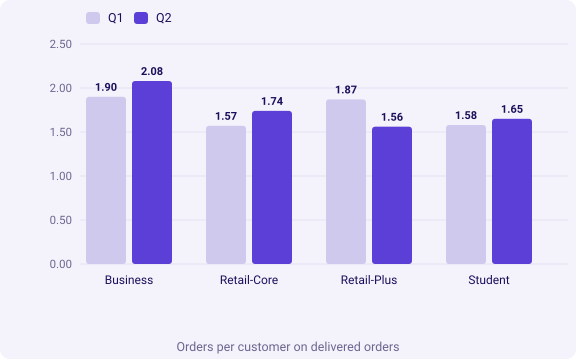

In [6]:
kit.check("your predicted row count matches the rows the query returned", PREDICTED_ROWS == len(seg),
          f"predicted {PREDICTED_ROWS}, returned {len(seg)}")
kit.check("every ratio multiplies back to its orders within half an order",
          all(abs(float(r["orders_per_customer"]) * r["customers"] - r["orders"]) < 0.5 for r in seg))
by = {(r["segment"], r["quarter"]): r for r in seg}
kit.columns(sorted({r["segment"] for r in seg}),
            [(q, [float(by[(s, q)]["orders_per_customer"]) for s in sorted({r["segment"] for r in seg})])
             for q in ("Q1", "Q2")], title="Orders per customer on delivered orders", fmt=lambda v: f"{v:.2f}")

In [7]:
# TODO 5. Which clause, after the grouping, lists the segment-quarters Kavya flags as too thin?
#   a) HAVING count(DISTINCT o.customer_id) < 30, since the bar is on customers per group
#   b) HAVING count(*) < 30, since a thin group is one with few orders
#   c) HAVING count(DISTINCT o.customer_id) <= 30, since a group on exactly 30 is thin too
#   d) HAVING count(o.customer_id) < 30, since it counts the customer column
THIN = {"a": "HAVING count(DISTINCT o.customer_id) < 30", "b": "HAVING count(*) < 30",
        "c": "HAVING count(DISTINCT o.customer_id) <= 30", "d": "HAVING count(o.customer_id) < 30"}["a"]
thin_sql = f"""SELECT c.segment, o.quarter, count(DISTINCT o.customer_id) AS customers
FROM orders o JOIN customers c USING (customer_id) {FILTER} GROUP BY c.segment, o.quarter {THIN} ORDER BY 1, 2"""
thin = rows(thin_sql)
show(thin, "The segment-quarters to flag")
flagged = {(r["segment"], r["quarter"]) for r in thin}
under_bar = {k for k, r in by.items() if r["customers"] < 30}
kit.check("the flagged groups are exactly the groups under Kavya's bar", flagged == under_bar,
          f"{len(flagged)} flagged against {len(under_bar)} under the bar")

segment,quarter,customers
Business,Q2,26
Student,Q1,12
Student,Q2,17


## Part 3. Which branch of Retail-Plus's tree moved furthest, and how much less did each member spend?

Where this is used at work: a head of a customer tier asks what each member is worth now, and
the answer has to count the members who stopped.

segment,customers_ratio,frequency_ratio,order_value_ratio,revenue_ratio
Business,0.867,1.093,1.035,0.98
Retail-Core,0.849,1.108,1.035,0.973
Retail-Plus,0.74,0.835,1.049,0.648
Student,1.417,1.04,0.919,1.354


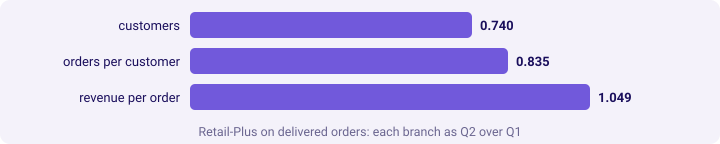

In [8]:
branches = rows(f"""
WITH book AS (
    SELECT o.customer_id, o.quarter, o.amount, c.segment
    FROM orders o JOIN customers c USING (customer_id) {FILTER}),
q1 AS (SELECT segment, count(DISTINCT customer_id) AS customers, count(*) AS orders, sum(amount) AS revenue
       FROM book WHERE quarter = 'Q1' GROUP BY segment),
q2 AS (SELECT segment, count(DISTINCT customer_id) AS customers, count(*) AS orders, sum(amount) AS revenue
       FROM book WHERE quarter = 'Q2' GROUP BY segment)
SELECT segment,
       round(q2.customers::numeric / q1.customers, 3) AS customers_ratio,
       round((q2.orders::numeric / q2.customers) / (q1.orders::numeric / q1.customers), 3) AS frequency_ratio,
       round((q2.revenue / q2.orders) / (q1.revenue / q1.orders), 3) AS order_value_ratio,
       round(q2.revenue / q1.revenue, 3) AS revenue_ratio
FROM q1 JOIN q2 USING (segment) ORDER BY segment""")
show(branches, "Each branch, Q2 over Q1, on delivered orders")
plus = next(r for r in branches if r["segment"] == "Retail-Plus")
kit.bars([("customers", plus["customers_ratio"]), ("orders per customer", plus["frequency_ratio"]),
          ("revenue per order", plus["order_value_ratio"])], fmt=lambda v: f"{v:.3f}",
         title="Retail-Plus on delivered orders: each branch as Q2 over Q1")
kit.check("the branches multiply back to the revenue ratio in every segment",
          all(abs(r["customers_ratio"] * r["frequency_ratio"] * r["order_value_ratio"] - r["revenue_ratio"]) < 0.002
              for r in branches))

In [9]:
# TODO 6. Which expression averages each quarter's spend over every member in the step?
#   a) avg(q2_spend)
#   b) sum(q2_spend) / count(q2_spend)
#   c) avg(coalesce(q2_spend, 0))
#   d) sum(q2_spend) / 120
SPEND = {"a": "avg({col})", "b": "sum({col}) / count({col})", "c": "avg(coalesce({col}, 0))",
         "d": "sum({col}) / 120"}["c"]

# TODO 7. Which pair of counts shows who is inside each quarter's average?
#   a) sum(q1_spend) and sum(q2_spend)
#   b) count(DISTINCT q1_spend) and count(DISTINCT q2_spend)
#   c) avg(q1_spend) and avg(q2_spend)
#   d) count(q1_spend) and count(q2_spend) beside count(*)
WHO = {"a": "sum(q1_spend) AS inside_q1, sum(q2_spend) AS inside_q2",
       "b": "count(DISTINCT q1_spend) AS inside_q1, count(DISTINCT q2_spend) AS inside_q2",
       "c": "avg(q1_spend) AS inside_q1, avg(q2_spend) AS inside_q2",
       "d": "count(q1_spend) AS inside_q1, count(q2_spend) AS inside_q2"}["d"]

spend_sql = f"""WITH member_spend AS (
    SELECT o.customer_id,
           sum(CASE WHEN o.quarter = 'Q1' THEN o.amount END) AS q1_spend,
           sum(CASE WHEN o.quarter = 'Q2' THEN o.amount END) AS q2_spend
    FROM orders o JOIN customers c USING (customer_id)
    {FILTER} AND c.segment = 'Retail-Plus'
    GROUP BY o.customer_id)
SELECT count(*) AS members, {WHO},
       round({SPEND.format(col='q1_spend')}) AS q1_average, round({SPEND.format(col='q2_spend')}) AS q2_average
FROM member_spend"""
print(spend_sql)
spend = rows(spend_sql)[0]
show([spend], "Retail-Plus spend per member on delivered orders", money=("q1_average", "q2_average"))

WITH member_spend AS (
    SELECT o.customer_id,
           sum(CASE WHEN o.quarter = 'Q1' THEN o.amount END) AS q1_spend,
           sum(CASE WHEN o.quarter = 'Q2' THEN o.amount END) AS q2_spend
    FROM orders o JOIN customers c USING (customer_id)
    WHERE status = 'delivered' AND c.segment = 'Retail-Plus'
    GROUP BY o.customer_id)
SELECT count(*) AS members, count(q1_spend) AS inside_q1, count(q2_spend) AS inside_q2,
       round(avg(coalesce(q1_spend, 0))) AS q1_average, round(avg(coalesce(q2_spend, 0))) AS q2_average
FROM member_spend


members,inside_q1,inside_q2,q1_average,q2_average
93,77,57,"Rs 4,356","Rs 2,823"


In [10]:
tier = rows(f"""SELECT o.quarter, sum(o.amount) AS revenue, count(DISTINCT o.customer_id) AS took_delivery
               FROM orders o JOIN customers c USING (customer_id)
               {FILTER} AND c.segment = 'Retail-Plus' GROUP BY o.quarter ORDER BY o.quarter""")
n = spend["members"]
kit.check(f"each average times the {n} members in the step gives back its quarter's tier revenue",
          all(abs(float(spend[a]) * n - tier[i]["revenue"]) <= n / 2 + 1
              for i, a in enumerate(("q1_average", "q2_average"))),
          f"{kit.rupees(float(spend['q1_average']) * n)} and {kit.rupees(float(spend['q2_average']) * n)} "
          f"against {kit.rupees(tier[0]['revenue'])} and {kit.rupees(tier[1]['revenue'])}")
kit.check("the pair matches the members who took delivery in each quarter, counted on their own",
          spend["inside_q1"] == tier[0]["took_delivery"] and spend["inside_q2"] == tier[1]["took_delivery"],
          f"{spend['inside_q1']} and {spend['inside_q2']} against {tier[0]['took_delivery']} and {tier[1]['took_delivery']}")

## Part 4. Does the suite add up the way the analyst will add it?

Where this is used at work: every report that shows a total beside its parts is added up by
someone before it is believed.

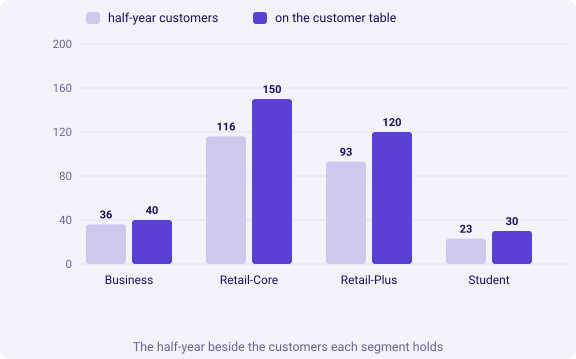

In [11]:
per_q = rows(f"""SELECT c.segment, o.quarter, count(DISTINCT o.customer_id) AS customers
               FROM orders o JOIN customers c USING (customer_id) {FILTER}
               GROUP BY c.segment, o.quarter ORDER BY 1, 2""")
# TODO 8. Predict before you run it. Business took delivery from 30 customers in Q1 and 26 in Q2,
#         and 20 of them in both quarters. How many Business customers took delivery in the half-year?
#   a) 56, the two quarters' customers added
#   b) 36, each of the customers counted once
#   c) 30, the larger of the two quarters
#   d) 10, the Q1 customers who did not return
PREDICTED_BUSINESS = {"a": 56, "b": 36, "c": 30, "d": 10}["b"]
quarters = {}
for r in per_q:
    quarters.setdefault(r["segment"], []).append(r["customers"])
half = {r["segment"]: r["customers"] for r in rows(
    f"""SELECT c.segment, count(DISTINCT o.customer_id) AS customers FROM orders o JOIN customers c USING (customer_id)
        {FILTER} GROUP BY c.segment ORDER BY 1""")}
members = {r["segment"]: r["members"] for r in rows(
    "SELECT segment, count(*) AS members FROM customers GROUP BY segment ORDER BY segment")}
kit.columns(sorted(half), [("half-year customers", [half[s] for s in sorted(half)]),
                           ("on the customer table", [members[s] for s in sorted(half)])],
            title="The half-year beside the customers each segment holds")

In [12]:
both = {r["segment"]: r["both"] for r in rows(f"""
    WITH per AS (SELECT c.segment, o.customer_id, count(DISTINCT o.quarter) AS quarters
                 FROM orders o JOIN customers c USING (customer_id) {FILTER} GROUP BY 1, 2)
    SELECT segment, count(*) FILTER (WHERE quarters = 2) AS both FROM per GROUP BY 1""")}
kit.check("your prediction for Business matches its half-year counted from the orders",
          PREDICTED_BUSINESS == half["Business"], f"predicted {PREDICTED_BUSINESS}, counted {half['Business']}")
kit.check("no segment's half-year exceeds the customers it holds", all(half[s] <= members[s] for s in half))
kit.check("each half-year equals Q1 plus Q2 less the customers in both",
          all(half[s] == sum(quarters[s]) - both[s] for s in half))

## Part 5. Will the analyst's rerun draw the same sample, and what does the run print beside it?

Where this is used at work: whenever an auditor traces a sample of orders and reruns the query
the next week, the sample has to come back the same, and the fingerprint tells a changed book
from a changed query.

order_id,amount
KR-00539,Rs 850
KR-00541,"Rs 1,160"
KR-00550,"Rs 1,480"
KR-00551,"Rs 1,500"
KR-00552,Rs 880


rows,rupees,customers
653,"Rs 13,45,90,290",268


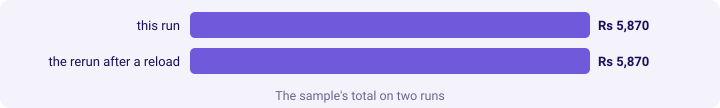

In [13]:
# TODO 9. Which ordering makes the five delivered Q2 web orders the same five on every run?
#   a) ORDER BY customer_id
#   b) ORDER BY order_id
#   c) no ORDER BY, only LIMIT 5
#   d) ORDER BY quarter
ORDERING = {"a": "ORDER BY customer_id", "b": "ORDER BY order_id", "c": "", "d": "ORDER BY quarter"}["b"]

# TODO 10. What should the fingerprint printed beside the delivered suite hold?
#   a) The delivered book's rows, rupees and distinct customers, three numbers
#   b) The count of order rows alone, the one number every reload changes
#   c) The delivered book's rows and distinct customers, the suite's own two counts
#   d) The row count and the latest order date, so a late order shows up
FINGER = {"a": "count(*) AS rows, sum(amount) AS rupees, count(DISTINCT customer_id) AS customers",
          "b": "count(*) AS rows", "c": "count(*) AS rows, count(DISTINCT customer_id) AS customers",
          "d": "count(*) AS rows, max(order_date) AS latest_order"}["a"]

sample_sql = f"""SELECT order_id, amount FROM orders
WHERE quarter = 'Q2' AND channel = 'web' AND status = 'delivered' {ORDERING} LIMIT 5"""
first = rows(sample_sql)
conn = kit.connect()
try:
    kit.sql("UPDATE orders SET status = status WHERE order_id IN "
            "(SELECT order_id FROM orders WHERE quarter = 'Q2' AND channel = 'web' AND status = 'delivered' "
            "ORDER BY order_id LIMIT 2)", conn=conn)
    second = [{k: num(v) for k, v in r.items()} for r in kit.sql(sample_sql, conn=conn)]
finally:
    conn.rollback()
    conn.close()
finger = rows(f"SELECT {FINGER} FROM orders {FILTER}")[0]
conn = kit.connect()
try:
    kit.sql("UPDATE orders SET amount = amount + 100 WHERE order_id = "
            "(SELECT min(order_id) FROM orders WHERE status = 'delivered')", conn=conn)
    corrected = [{k: num(v) for k, v in r.items()} for r in kit.sql(f"SELECT {FINGER} FROM orders {FILTER}", conn=conn)][0]
finally:
    conn.rollback()
    conn.close()
column = ORDERING.replace("ORDER BY", "").strip()
spread = rows(f"""SELECT count(*) AS candidates, count(DISTINCT {column or "1"}) AS values
    FROM orders WHERE quarter = 'Q2' AND channel = 'web' AND status = 'delivered'""")[0]
show(first, "The sample on this run", money=("amount",))
show([finger], "The delivered book's fingerprint", money=("rupees",))
kit.bars([("this run", sum(r["amount"] for r in first)), ("the rerun after a reload", sum(r["amount"] for r in second))],
         fmt=kit.rupees, title="The sample's total on two runs")

In [14]:
kit.check("the ordering column takes a different value on every candidate",
          bool(column) and spread["values"] == spread["candidates"],
          f"{spread['values'] if column else 'no'} values over {spread['candidates']} candidates")
kit.check("the rerun after a reload draws the same five", [r["order_id"] for r in first] == [r["order_id"] for r in second])
kit.check("the fingerprint's rows equal the delivered book's orders",
          finger.get("rows") == book["Q1"]["orders"] + book["Q2"]["orders"])
kit.check("the fingerprint moves when one delivered amount is corrected by Rs 100", corrected != finger)

**Why each key holds.** 1 b keeps only delivered orders; a keeps the 184 returned orders, d keeps
the 163 cancelled ones, and c keeps all 1,000, since no amount is zero or below. 2 c counts each
customer once; a and d count rows, and b counts rows with a customer id, which is every row. 3 a:
grouping by segment and quarter makes one row for each of four segments in each of two quarters,
and every segment took delivery in both. 4 d divides in `numeric`; a rounds an integer division
that already dropped the fraction, b is the integer division itself, and c divides the wrong way
round. 5 a tests each group's customers after grouping; b and d count orders, which flags Student
alone and misses Business Q2's 26 customers, and c also flags Business Q1, which stands on exactly
30. 6 c writes Rs 0 on purpose, so both quarters average over every member in the step; a and b
skip the members with no delivery in the quarter, and d divides by the 120 members on the
customers table, 27 of whom took no delivery in either quarter. 7 d counts the values inside each
average; a and c add or average, and b counts distinct amounts, so two members who spent the same
count once. 8 b: 30 plus 26 less the 20 in both is 36; a counts the 20 twice, c leaves out the 6
who took delivery only in Q2, and d counts only the Q1 customers who did not come back. 9 b orders
on the table's key, which takes a different value on each of the 93 candidates; a orders on the
customer id, and the 93 candidates belong to only 76 customers, c is the unordered sample, and d
orders on a value every candidate shares. 10 a is the fingerprint; b, c and d stay put when an
amount is corrected, since none of them carries the rupees.

**Post your answer.** Ten letters, in the order of the markers, as one line, and beside them the
three numbers the brief asks for: Q2's delivered revenue, Retail-Plus's Q2 orders per customer,
and Retail-Plus's half-year customers.

In [15]:
kit.check_summary()